In [1]:
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

In [2]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프의 노드와 엣지가 뭐야?')

{'query': '랭그래프의 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다 - 티스토리',
   'content': '2.1. 엣지 개념. 엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.',
   'score': 0.852752,
   'raw_content': None,
   'id': 'acba54-00'},
  {'url': 'https://velog.io/@ohback/LangGraph',
   'title': 'LangGraph란 무엇이고 언제 쓰면 좋을까?',
   'content': '위 코드에서 상태, 노드, 엣지는 다음과 같다.\n\n 상태(State): 질문, 후보 문서 목록, 현재까지의 답변, 재시도 횟수 등\n 노드(Nodes): `retrieve`, `grade_docs`, `generate`, `decide_more`\n 엣지(Edges): `START → retrieve → grade_docs → generate → decide_more → (END 또는 retrieve로 루프)`\n\n간단히 말해서, 노드는 작업을 수행하고, 에지는 다음에 무엇을 할지 알려준다.\n\n  \n\n## 핵심 활용 분야\n\nLangGraph의 강점은 상태 기반(Stateful) LLM 오케스트레이션이다.  \n 이러한 강점을 활용한 예시는 다음과 같다: [...] 여기서 등장하는 게 LangGraph다. 이름 그대로 그래프(노드/엣지)로 LLM 애플리케이션의 흐름을 설계한다.  \n La

In [3]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model 
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage # 메시지 타입


# 그래프에서 사용할 상태(TypedDict) 스키마 
class State(TypedDict):
    messages: Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.6-luna')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩



# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):   # ← 타입 힌트는 대문자 State
    response = llm.invoke(state['messages']) # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}          # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [4]:
from langchain_core.messages import ToolMessage # 툴 실행 결과를 담을 메시지 타입
import json # json 문자열 파싱

# tool call을 실행하는 노드 클래스
class ToolNode:
    def __init__(self,tools):
        self.tools_by_name = {tool.name: tool for tool in tools} # {tool_name: tool 객체}

    def __call__(self, inputs: State):
        '''
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.
        '''

        # messages가 있으면 마지막 메시지 가져오고, 아니면 에러발생
        if messages := inputs.get("messages"):
            message = messages[-1]  # 마지막 메시지(AI Message)는 도구 호출 대상
        else:
            raise ValueError("메시지가 없습니다.")
        
        outputs = [] # ToolMessage들을 담을 리스트
        for tool_call in messages.tool_calls:
            # tool 이름을 찾아 실행 (매개변수는 ai메시지에서 전달한 입력매개변수)
            tool_result = self.tool_by_name[tool_call['name']].invoke(tool_call['args'])
            tool_message = ToolMessage(
                content = json.dump(tool_result), # 결과를 json으로 파싱
                name = tool_call['name'],
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)

        return {"messages": outputs}

In [ ]:
# 도구 호출 여부에 따른 분기 함수(tools_condition) 
# - 다음 분기로 tools로 보낼지 아니면 END로 끝낼지 결정
from pprint import pprint

def tools_condition(state: State):
    pprint(state['messages'])

    if isinstance(state,list):   # state가 list형태일 경우 (MessageGraph)
        ai_message = state[-1]   # 마지막 메시지는 AIMessage
    elif messages := state.get("messages", []): # state가 dict 형태(StateGraph)인 경우
        ai_message = messages[-1]
    else:
        raise ValueError("State의 tool_edge에서 들어온 메시지 확인 불가: {state}")
    
    # AIMessage에 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'

    # tool_calls가 없으면 END 노드로 이동    
    return END


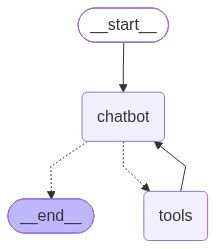

In [6]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)
 
workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot) # chatbot 노드
workflow.add_node('tools', tool_node) # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END: END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile() # 설계된 워크플로우를 실행 가능한 그래프로 컴파일
 
graph

In [8]:
user_query = '랭그래프의 구성요소는?'

state = {'messages': [HumanMessage(content=user_query)]}

response = graph.invoke(state)
print('='*100)
print(response['messages'][-1].content)

[HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='17a3f784-e2f6-4858-85d7-bf3519a69745'),
 AIMessage(content='랭그래프(LangGraph)의 주요 구성요소는 다음과 같습니다.\n\n1. **State(상태)**\n   - 그래프 실행 중 노드들이 공유하는 데이터입니다.\n   - 대화 메시지, 사용자 입력, 중간 결과, 실행 단계 등을 저장합니다.\n   - 보통 `TypedDict`, `dataclass`, Pydantic 모델 등으로 정의합니다.\n\n2. **Node(노드)**\n   - 상태를 입력받아 작업을 수행하고, 상태의 일부를 업데이트하는 함수입니다.\n   - 예: LLM 호출, 도구 실행, 검색, 문서 평가, 사용자 승인 처리 등\n\n3. **Edge(엣지)**\n   - 노드 간 실행 흐름을 연결합니다.\n   - 일반 엣지: 항상 다음 노드로 이동\n   - 조건부 엣지: 상태에 따라 다음 노드를 선택\n\n4. **START / END**\n   - `START`: 그래프 실행 시작점\n   - `END`: 그래프 실행 종료점\n\n5. **Graph 또는 StateGraph**\n   - 상태, 노드, 엣지를 조합해 전체 실행 흐름을 정의하는 구조입니다.\n   - 일반적으로 `StateGraph`를 사용해 상태 기반 워크플로를 만듭니다.\n\n6. **Reducer**\n   - 여러 노드의 결과를 상태에 어떻게 합칠지 결정합니다.\n   - 예를 들어 메시지 목록에 새 메시지를 추가하거나, 기존 값을 덮어쓸 수 있습니다.\n\n7. **Conditional Routing**\n   - 조건에 따라 실행 경로를 분기하는 기능입니다.\n   - 에이전트가 도구를 호출할지, 답변을 종료할지 결정하는 데 자주 사용됩니다.\n\n8. **Checkpoint / Persistence**\n  